# Задание 9. Первая нейросеть на PyTorch: регрессия

Что нужно сделать:
- поставить PyTorch и разобрать базовую модель нейронной сети для регрессии;
- решить задачу прогнозирования целевой переменной на датасете possum (openintro-possum),
  целевая переменная — **возраст опоссума** (`age`);
- привести графики изменения функции ошибки и метрики по эпохам для обучающего и для тестового набора
  (всего 4 графика);
- привести итоговые метрики MAE, MSE, RMSE, R2 для обучающего набора;
- привести график, сопоставляющий прогнозы и правильные ответы всех объектов датасета.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

print("версия torch:", torch.__version__)

версия torch: 2.14.0


## Часть 1. Данные

### Шаг 1. Читаем датасет и смотрим, что внутри

In [2]:
df = pd.read_csv("possum.csv")
df.head()

,rownames,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,C3,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,C5,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,C10,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,C15,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,C23,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  104 non-null    str    
 1   case      104 non-null    int64  
 2   site      104 non-null    int64  
 3   Pop       104 non-null    str    
 4   sex       104 non-null    str    
 5   age       102 non-null    float64
 6   hdlngth   104 non-null    float64
 7   skullw    104 non-null    float64
 8   totlngth  104 non-null    float64
 9   taill     104 non-null    float64
 10  footlgth  103 non-null    float64
 11  earconch  104 non-null    float64
 12  eye       104 non-null    float64
 13  chest     104 non-null    float64
 14  belly     104 non-null    float64
dtypes: float64(10), int64(2), str(3)
memory usage: 12.3 KB


In [4]:
df.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


In [5]:
# пропуски есть, посмотрим где именно
df.isnull().sum()

rownames    0
case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

104 объекта и 14 столбцов. Целевая переменная `age` — возраст в годах, от 1 до 9, в среднем около 3.8.
Пропуски есть в двух столбцах: 2 пропуска в `age` и 1 в `footlgth`.

### Шаг 2. Готовим данные: идентификаторы, пропуски, категориальные признаки

In [6]:
# rownames и case - это номера животных, никакой информации о возрасте в них нет
df = df.drop(["rownames", "case"], axis=1)

In [7]:
# строки без age выбрасываем: обучаться без правильного ответа не на чем, а придумывать
# целевую переменную самому нельзя
print("строк с пропущенным age:", df["age"].isnull().sum())
df = df.dropna(subset=["age"]).reset_index(drop=True)
print("осталось объектов:", len(df))

строк с пропущенным age: 2
осталось объектов: 102


In [8]:
# Pop и sex - категориальные, кодируем числами (по два значения в каждом, так что хватит 0/1)
print(df["Pop"].value_counts())
print(df["sex"].value_counts())

df["Pop"] = df["Pop"].map({"Vic": 0, "other": 1})
df["sex"] = df["sex"].map({"f": 0, "m": 1})
df.head()

Pop
other    58
Vic      44
Name: count, dtype: int64
sex
m    59
f    43
Name: count, dtype: int64


,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,0,1,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,0,0,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,0,0,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,0,0,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,0,0,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [9]:
X = df.drop("age", axis=1).values.astype(np.float32)
y = df["age"].values.astype(np.float32)
feature_names = list(df.drop("age", axis=1).columns)

print("признаков:", X.shape[1], "|", feature_names)
print("объектов:", X.shape[0])

признаков: 12 | ['site', 'Pop', 'sex', 'hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly']
объектов: 102


Что сделано с пропусками: 2 строки с пропущенным `age` удалены (без целевой переменной объект бесполезен),
осталось 102 объекта. Единственный пропуск в `footlgth` заполним ниже — уже после разбиения на выборки,
медианой по обучающей части, чтобы не занести в обучение информацию о тесте.

### Шаг 3. Делим на обучающую и тестовую выборки

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("обучающая:", X_train.shape, " тестовая:", X_test.shape)

обучающая: (76, 12)  тестовая: (26, 12)


In [11]:
# добиваем пропуск в footlgth медианой, посчитанной ТОЛЬКО по обучающей выборке
foot = feature_names.index("footlgth")
foot_median = np.nanmedian(X_train[:, foot])
print("медиана footlgth по обучающей выборке =", foot_median)

X_train[np.isnan(X_train[:, foot]), foot] = foot_median
X_test[np.isnan(X_test[:, foot]), foot] = foot_median
print("пропусков осталось:", np.isnan(X_train).sum(), np.isnan(X_test).sum())

медиана footlgth по обучающей выборке = 67.75
пропусков осталось: 0 0


### Шаг 4. Масштабируем признаки

Признаки в очень разных масштабах (длина головы около 90, а `sex` это 0/1), и нейросеть на таких данных
учится плохо. Приводим к $x_{norm} = (x - mean)/std$, причем `mean` и `std` считаем **только по обучающей
выборке** и этими же числами преобразуем тестовую — иначе информация о тесте протечет в обучение.

Целевую переменную не масштабируем: возраст и так лежит в диапазоне 1..9, а метрики так сразу получаются
в годах и их удобно читать.

In [12]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_n = (X_train - X_mean) / X_std
X_test_n = (X_test - X_mean) / X_std

# проверим, что у обучающей выборки среднее 0 и стандартное отклонение 1
print(X_train_n.mean(axis=0).round(3))
print(X_train_n.std(axis=0).round(3))

[-0.  0. -0.  0. -0.  0.  0. -0.  0.  0.  0. -0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Шаг 5. Переводим данные в тензоры

PyTorch работает не с массивами numpy, а со своими тензорами. Целевую переменную делаем столбиком
(`reshape(-1, 1)`), потому что выход сети — это тоже один нейрон на объект.

In [13]:
X_train_t = torch.tensor(X_train_n, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test_n, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print(X_train_t.shape, y_train_t.shape)
print(X_test_t.shape, y_test_t.shape)

torch.Size([76, 12]) torch.Size([76, 1])
torch.Size([26, 12]) torch.Size([26, 1])


In [14]:
# DataLoader сам нарежет обучающую выборку на батчи по 32 объекта и перемешает их на каждой эпохе
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("батчей в эпохе:", len(train_loader))

батчей в эпохе: 3


## Часть 2. Модель нейронной сети

### Шаг 6. Описываем сеть

Обычная полносвязная сеть: два скрытых слоя с ReLU и один выходной нейрон без активации — это и есть
предсказанный возраст. Функция ошибки для регрессии — `nn.MSELoss`, оптимизатор — Adam с `lr=0.001`.

In [15]:
class Net(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)      # один выход - число, возраст
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)


model = Net(X_train_t.shape[1])
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

Net(
  (fc1): Linear(in_features=12, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


### Шаг 7. Обучаем

Один шаг обучения выглядит всегда одинаково: обнулить градиенты, сделать прогноз, посчитать ошибку,
`backward()` и `step()`. После каждой эпохи считаем ошибку (MSE) и метрику (MAE) сразу на обеих выборках
и складываем в списки — из них потом получатся 4 графика.

In [16]:
n_epochs = 200

train_loss_hist = []
test_loss_hist = []
train_mae_hist = []
test_mae_hist = []

for epoch in range(n_epochs):
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()             # обнуляем градиенты с прошлого шага
        pred = model(x_batch)             # прямой проход
        loss = loss_fn(pred, y_batch)     # ошибка на батче
        loss.backward()                   # считаем градиенты
        optimizer.step()                  # обновляем веса

    # после эпохи смотрим качество на всей обучающей и всей тестовой выборке
    model.eval()
    with torch.no_grad():
        pred_train = model(X_train_t)
        pred_test = model(X_test_t)

        train_loss_hist.append(loss_fn(pred_train, y_train_t).item())
        test_loss_hist.append(loss_fn(pred_test, y_test_t).item())
        train_mae_hist.append((pred_train - y_train_t).abs().mean().item())
        test_mae_hist.append((pred_test - y_test_t).abs().mean().item())

    if (epoch + 1) % 20 == 0:
        print(f"эпоха {epoch + 1:3d}   train MSE {train_loss_hist[-1]:.3f}   test MSE {test_loss_hist[-1]:.3f}"
              f"   train MAE {train_mae_hist[-1]:.3f}   test MAE {test_mae_hist[-1]:.3f}")

эпоха  20   train MSE 12.415   test MSE 13.072   train MAE 3.019   test MAE 2.986
эпоха  40   train MSE 4.488   test MSE 4.506   train MAE 1.659   test MAE 1.633
эпоха  60   train MSE 3.264   test MSE 3.964   train MAE 1.409   test MAE 1.534
эпоха  80   train MSE 2.717   test MSE 3.901   train MAE 1.298   test MAE 1.511
эпоха 100   train MSE 2.361   test MSE 3.804   train MAE 1.240   test MAE 1.506
эпоха 120   train MSE 2.045   test MSE 3.733   train MAE 1.146   test MAE 1.482
эпоха 140   train MSE 1.771   test MSE 3.622   train MAE 1.058   test MAE 1.473
эпоха 160   train MSE 1.532   test MSE 3.566   train MAE 0.972   test MAE 1.467
эпоха 180   train MSE 1.315   test MSE 3.495   train MAE 0.896   test MAE 1.485
эпоха 200   train MSE 1.122   test MSE 3.436   train MAE 0.827   test MAE 1.468


## Часть 3. Графики по эпохам (4 графика)

Функция ошибки — MSE (та самая, которую минимизирует сеть), метрика — MAE, средняя ошибка в годах.

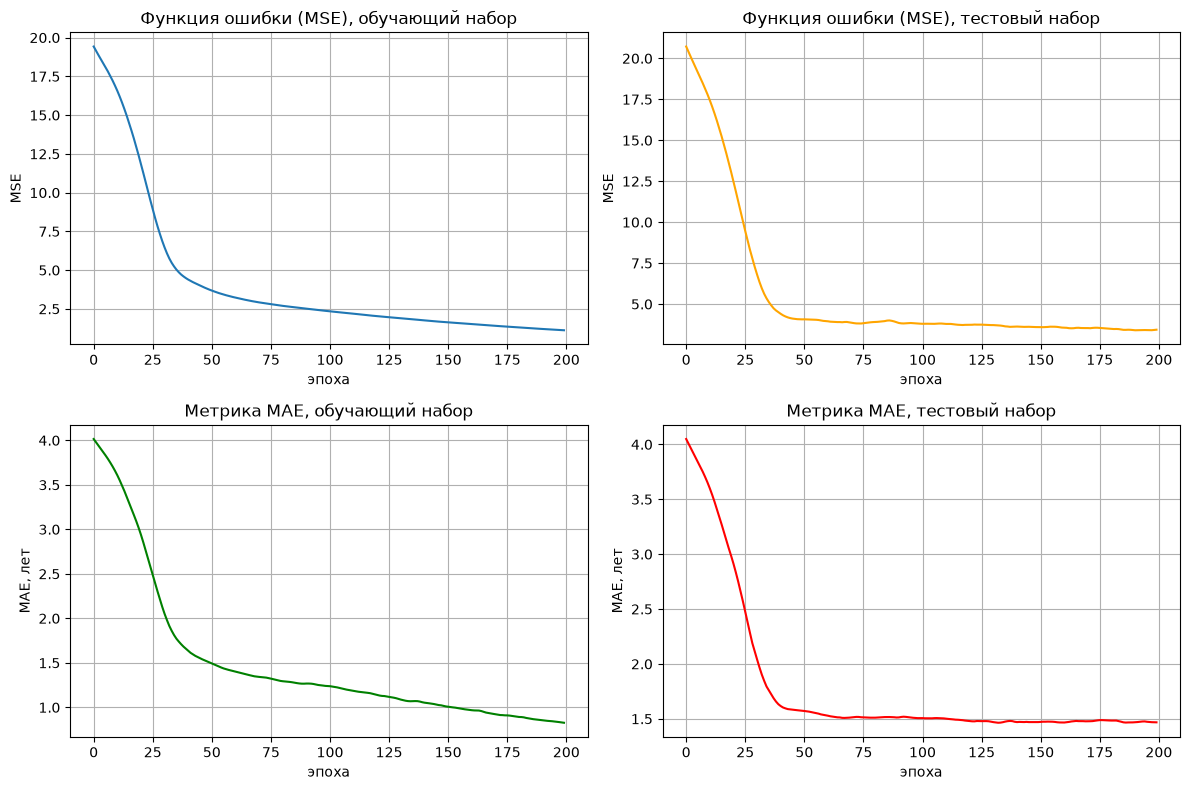

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(train_loss_hist)
axes[0, 0].set_title("Функция ошибки (MSE), обучающий набор")
axes[0, 0].set_ylabel("MSE")

axes[0, 1].plot(test_loss_hist, color="orange")
axes[0, 1].set_title("Функция ошибки (MSE), тестовый набор")
axes[0, 1].set_ylabel("MSE")

axes[1, 0].plot(train_mae_hist, color="green")
axes[1, 0].set_title("Метрика MAE, обучающий набор")
axes[1, 0].set_ylabel("MAE, лет")

axes[1, 1].plot(test_mae_hist, color="red")
axes[1, 1].set_title("Метрика MAE, тестовый набор")
axes[1, 1].set_ylabel("MAE, лет")

for ax in axes.flatten():
    ax.set_xlabel("эпоха")
    ax.grid(True)

plt.tight_layout()
plt.show()

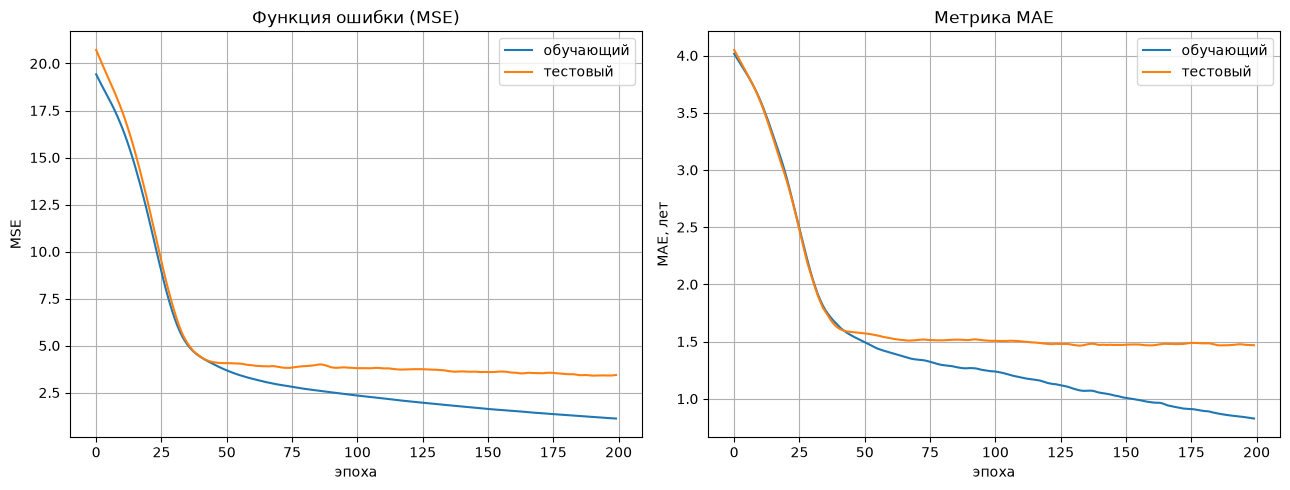

In [18]:
# те же кривые, наложенные друг на друга - так видно расхождение обучения и теста
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(train_loss_hist, label="обучающий")
axes[0].plot(test_loss_hist, label="тестовый")
axes[0].set_title("Функция ошибки (MSE)")
axes[0].set_ylabel("MSE")

axes[1].plot(train_mae_hist, label="обучающий")
axes[1].plot(test_mae_hist, label="тестовый")
axes[1].set_title("Метрика MAE")
axes[1].set_ylabel("MAE, лет")

for ax in axes:
    ax.set_xlabel("эпоха")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Первые примерно 40 эпох обе кривые падают вместе и очень быстро: сеть с нуля доучивается хотя бы
предсказывать средний возраст. Дальше поведение расходится — на обучающем наборе ошибка продолжает
монотонно уменьшаться (MSE с 4 до 1.1), а на тестовом выходит на полку около MSE 3.5 и MAE 1.5 года и
больше не улучшается. Это переобучение: обучающих объектов всего 76, а параметров в сети несколько сотен,
поэтому сеть постепенно запоминает конкретных опоссумов вместо общей зависимости.

## Часть 4. Итоговые метрики

In [19]:
# метрики регрессии, чтобы не писать их несколько раз
def print_metrics(y_true, y_pred):
    print("MAE  =", mean_absolute_error(y_true, y_pred))
    print("MSE  =", mean_squared_error(y_true, y_pred))
    print("RMSE =", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2   =", r2_score(y_true, y_pred))

In [20]:
model.eval()
with torch.no_grad():
    pred_train = model(X_train_t).numpy().flatten()
    pred_test = model(X_test_t).numpy().flatten()

print("--- обучающий набор ---")
print_metrics(y_train, pred_train)
print()
print("--- тестовый набор ---")
print_metrics(y_test, pred_test)

--- обучающий набор ---
MAE  = 0.8273266553878784
MSE  = 1.1224032640457153
RMSE = 1.0594353515178334
R2   = 0.6651861667633057

--- тестовый набор ---
MAE  = 1.468304991722107
MSE  = 3.4361002445220947
RMSE = 1.8536720973575922
R2   = 0.21207475662231445


In [21]:
# то же самое таблицей, так удобнее сравнивать
pd.DataFrame({
    "обучающий": [mean_absolute_error(y_train, pred_train),
                  mean_squared_error(y_train, pred_train),
                  np.sqrt(mean_squared_error(y_train, pred_train)),
                  r2_score(y_train, pred_train)],
    "тестовый": [mean_absolute_error(y_test, pred_test),
                 mean_squared_error(y_test, pred_test),
                 np.sqrt(mean_squared_error(y_test, pred_test)),
                 r2_score(y_test, pred_test)],
}, index=["MAE", "MSE", "RMSE", "R2"]).round(3)

,обучающий,тестовый
MAE,0.827,1.468
MSE,1.122,3.436
RMSE,1.059,1.854
R2,0.665,0.212


На обучающем наборе MAE = 0.83 года, RMSE = 1.06, $R^2 = 0.67$ — сеть объясняет две трети разброса возраста.
На тестовом наборе метрики заметно хуже: MAE = 1.47 года, RMSE = 1.85, $R^2 = 0.21$. Разрыв между
обучающей и тестовой выборкой и есть то самое переобучение, которое видно на графиках.

## Часть 5. Прогноз против правильных ответов для всех объектов датасета

In [22]:
# собираем прогнозы по всем 102 объектам: обучающие и тестовые вместе
y_all = np.concatenate([y_train, y_test])
pred_all = np.concatenate([pred_train, pred_test])

print("--- весь датасет ---")
print_metrics(y_all, pred_all)

--- весь датасет ---
MAE  = 0.9907132983207703
MSE  = 1.7121691703796387
RMSE = 1.3084988232243997
R2   = 0.5256462693214417


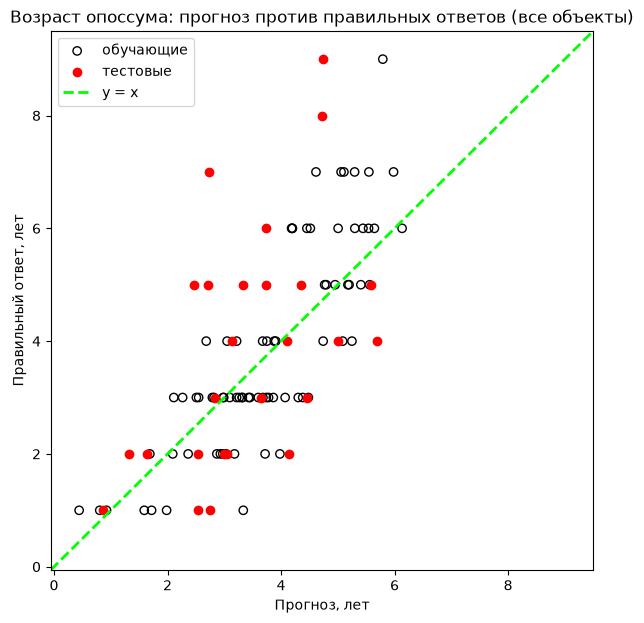

In [23]:
plt.figure(figsize=(7, 7))
plt.scatter(pred_train, y_train, facecolors="none", edgecolors="black", label="обучающие")
plt.scatter(pred_test, y_test, color="red", label="тестовые")

lims = [min(pred_all.min(), y_all.min()) - 0.5, max(pred_all.max(), y_all.max()) + 0.5]
plt.plot(lims, lims, "--", color="lime", linewidth=2, label="y = x")
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Прогноз, лет")
plt.ylabel("Правильный ответ, лет")
plt.title("Возраст опоссума: прогноз против правильных ответов (все объекты)")
plt.legend()
plt.show()

In [24]:
# несколько объектов в цифрах
pd.DataFrame({
    "правильный ответ": y_all[:15],
    "прогноз": pred_all[:15].round(2),
    "разница": (y_all[:15] - pred_all[:15]).round(2),
})

,правильный ответ,прогноз,разница
0,4.0,2.68,1.32
1,5.0,5.41,-0.41
2,3.0,2.11,0.89
3,6.0,5.00,1.00
4,2.0,3.03,-1.03
5,5.0,4.77,0.23
6,3.0,3.43,-0.43
7,3.0,3.26,-0.26
8,3.0,3.45,-0.45
9,4.0,4.74,-0.74


Точки в целом тянутся вдоль прямой $y = x$, то есть зависимость сеть поймала, но облако широкое и заметно
"поджато" по горизонтали: прогнозы почти все лежат в диапазоне 1..6 лет, тогда как настоящие возрасты
доходят до 9. Старых опоссумов сеть систематически недооценивает — их в датасете единицы, и ей выгоднее
тянуть прогноз к середине.

## Выводы

Первая нейросеть на PyTorch собрана и обучена: два скрытых слоя с ReLU, один выходной нейрон, `nn.MSELoss`,
Adam с `lr=0.001`, батч 32, 200 эпох. Порядок работы с данными соблюден: сначала разбиение на выборки,
потом заполнение пропуска и параметры масштабирования — только по обучающей части.

Качество получилось умеренным: MAE около 0.83 года на обучающем наборе и 1.47 года на тестовом при среднем
возрасте 3.8 года. Главная причина — размер датасета: 102 объекта после удаления пропусков, из них 76 на
обучение. На такой выборке сеть с несколькими сотнями параметров быстро начинает запоминать обучающие
объекты, поэтому тестовая ошибка выходит на полку уже к 40-й эпохе, пока обучающая продолжает падать.
Специально подгонять результат под красивую картинку смысла нет — переобучение здесь честное следствие
данных, а не ошибки в модели.